
# Homework 4 — Replicating ARK Invest’s “Big Ideas”: Bitcoin in a Mean–Variance Portfolio

## Overview
In this assignment, you will:
1. Collect ETF (and BTC) data from Yahoo Finance for key asset classes.
2. Construct daily (or weekly) log returns and annualize them.
3. Run a Monte Carlo simulation to approximate the *optimal risky portfolio* under mean–variance analysis.
4. Compare with the analytical tangency portfolio (closed-form solution under standard assumptions).
5. Discuss sensitivity to (a) ETF choices, (b) sample period, and (c) your risk-free rate assumption.
6. Reflect on how your results relate to ARK Invest’s **Big Ideas** narrative about Bitcoin’s role in diversified portfolios.

https://research.ark-invest.com/hubfs/1_Download_Files_ARK-Invest/White_Papers/ARK–Invest_BigIdeas_2021.pdf


In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



## 1. Setup

Run the cell below to (optionally) install packages in a local environment.
If you're on a managed environment (e.g. Google Colab),
you may skip the installation lines if the packages already exist.


In [3]:

# If needed, uncomment to install locally
# !pip install yfinance pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")



## 2. Choose Your Asset Universe

Select **one** ETF per asset class (you may change these! Just explain your choices later).  


- **Real Estate:**
- **Commodities (broad):**
- **Currencies (USD long):**
- **Investment-Grade Bonds:**
- **U.S. Equities:**
- **Gold:**
- **Bitcoin (spot price):** `BTC-USD` (Bitcoin price from Yahoo Finance)




## 3. Download & Prepare the Data


In [10]:
risky_assets= ['ADBE', 'AMZN', 'BX', 'GD', 'NKE', 'NVDA', 'SN', 'TSM', 'XOM', 'AVDV', 'BTC', 'FNDB', 'REZ', 'VUG', 'VXUS', 'TBIL']

prices = yf.download(risky_assets, period="5y", interval="1d", auto_adjust=True)["Close"].dropna()
prices = prices[prices.index.is_month_start]

[*********************100%***********************]  16 of 16 completed


In [11]:
prices

Ticker,ADBE,AMZN,AVDV,BTC,BX,FNDB,GD,NKE,NVDA,REZ,SN,TBIL,TSM,VUG,VXUS,XOM
Date,,,,,,,,,,,,,,,,
2024-08-01,546.409973,184.070007,62.183186,28.100000,130.722946,21.805683,283.682709,70.998520,109.157364,77.567627,76.269997,46.500023,154.575226,59.724869,57.212555,110.261765
2024-10-01,502.799988,185.130005,66.338791,27.400000,144.860870,22.732059,295.167267,86.070763,116.953613,84.983627,107.940002,46.912594,168.769348,62.695511,61.343117,113.981659
2024-11-01,482.799988,197.929993,63.078384,30.700001,161.228882,22.624878,284.603119,75.380714,135.346329,81.284492,89.120003,47.098072,189.248764,63.887218,58.825550,109.248657
2025-04-01,383.200012,192.169998,67.343773,37.650002,138.098373,22.641420,267.706757,63.174549,110.124054,84.384079,84.199997,47.921143,166.576859,62.091141,60.359001,115.085739
2025-05-01,374.630005,190.199997,69.487175,42.790001,129.907516,21.933569,266.609741,55.370403,111.583702,81.764488,79.809998,48.087502,170.606964,63.695816,61.735207,102.266205
2025-07-01,392.100006,220.460007,78.045441,46.660000,148.781555,23.965261,289.066956,72.088692,153.274536,81.130196,99.260002,48.419064,222.742767,72.097839,67.462128,106.583977
2025-08-01,347.799988,214.750000,78.999611,50.049999,165.951263,23.530788,306.696899,73.276917,173.691132,80.166229,112.320000,48.601871,233.181961,73.936958,66.612877,106.974251
2025-10-01,343.720001,220.630005,87.528160,52.049999,164.706924,25.584265,336.316437,73.243134,187.219452,84.130241,100.339996,48.946754,286.884949,80.139351,72.560539,110.283875
2025-12-01,322.850006,233.880005,90.715286,37.849998,144.668610,26.238747,329.497253,64.958832,179.900253,85.653580,101.389999,49.257481,286.099274,81.303543,73.227585,115.857765


In [12]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10 entries, 2024-08-01 to 2026-04-01
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ADBE    10 non-null     float64
 1   AMZN    10 non-null     float64
 2   AVDV    10 non-null     float64
 3   BTC     10 non-null     float64
 4   BX      10 non-null     float64
 5   FNDB    10 non-null     float64
 6   GD      10 non-null     float64
 7   NKE     10 non-null     float64
 8   NVDA    10 non-null     float64
 9   REZ     10 non-null     float64
 10  SN      10 non-null     float64
 11  TBIL    10 non-null     float64
 12  TSM     10 non-null     float64
 13  VUG     10 non-null     float64
 14  VXUS    10 non-null     float64
 15  XOM     10 non-null     float64
dtypes: float64(16)
memory usage: 1.3 KB


In [13]:
# calculate daily return
ret = prices.pct_change()

mean_ret = ret.mean()
print(mean_ret)

# get the covariance of returns of the stocks (this includes the variance of each stocks and the pairwise covariance)
cov = ret.cov()
print(cov)

# risk free rate
rF = 0
print(rF)

Ticker
ADBE   -0.082158
AMZN    0.017390
AVDV    0.057602
BTC     0.020611
BX     -0.006646
FNDB    0.025945
GD      0.024629
NKE    -0.033941
NVDA    0.064238
REZ     0.009390
SN      0.051435
TBIL    0.007791
TSM     0.099022
VUG     0.025275
VXUS    0.035999
XOM     0.049928
dtype: float64
Ticker      ADBE      AMZN      AVDV       BTC        BX      FNDB        GD  \
Ticker                                                                         
ADBE    0.009090  0.005927 -0.000654  0.003258  0.008378  0.001312  0.001376   
AMZN    0.005927  0.005414 -0.000252  0.001805  0.005972  0.001426  0.000381   
AVDV   -0.000654 -0.000252  0.003209 -0.002113 -0.002236  0.001868  0.001940   
BTC     0.003258  0.001805 -0.002113  0.026494  0.008574 -0.001860 -0.001802   
BX      0.008378  0.005972 -0.002236  0.008574  0.017679  0.000850  0.002404   
FNDB    0.001312  0.001426  0.001868 -0.001860  0.000850  0.001930  0.001640   
GD      0.001376  0.000381  0.001940 -0.001802  0.002404  0.001640

In [14]:
num_assets = 16
num_assets

16

In [15]:
weights = np.random.random(num_assets)
print(weights)
print('\n')

weights /= np.sum(weights)

print("A random set of weights: \n")
print(weights)

print(weights.sum())

[0.86136366 0.26315608 0.05465435 0.65505951 0.76088935 0.77033821
 0.74662582 0.77823534 0.98869761 0.61752969 0.60533336 0.53212806
 0.82535297 0.54251066 0.37627153 0.18134447]


A random set of weights: 

[0.0901056  0.02752825 0.00571729 0.06852452 0.07959518 0.0805836
 0.0781031  0.08140971 0.10342576 0.0645986  0.06332276 0.0556649
 0.08633859 0.056751   0.03936104 0.0189701 ]
1.0



## 4. Monte Carlo Mean–Variance Optimization

We will simulate many random portfolios with long-only, fully-invested weights (non-negative, sum to 1) and compute:
- expected return
- volatility
- Sharpe ratio (with a user-specified risk-free rate)

We then identify:
- **Max Sharpe (tangency) portfolio**
- **Min variance**


In [16]:
returns = np.dot(weights, mean_ret)
returns

np.float64(0.018828821053438607)

In [17]:
volatility = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
volatility

np.float64(0.07090186054919471)

In [18]:
sharpe = (returns-rF)/volatility
sharpe

np.float64(0.2655617343126613)


## 5. Analytical Tangency Portfolio



In [49]:
num_assets = 16
num_portfolios = 100000

# empty lists to store returns, volatility, sharoe-ratio, and weights of the 5000 portfolios
port_returns = []
port_volatility = []
port_sharpe = []
stock_weights = []

# iterate 500000 times, each time generate a set of random weights
for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    returns = np.dot(weights, mean_ret)
    volatility = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))

    sharpe = (returns-rF)/volatility

    port_returns.append(returns)
    port_volatility.append(volatility)
    port_sharpe.append(sharpe)
    stock_weights.append(weights)



In [50]:
# a dictionary for Returns and Risk values of each portfolio
portfolio = {'Returns': port_returns,
             'Volatility': port_volatility,
             'Sharpe Ratio': port_sharpe}

# extend original dictionary to accomodate each ticker and weight in the portfolio
for counter,symbol in enumerate(risky_assets):
    portfolio[symbol+' weight'] = [weight[counter] for weight in stock_weights]

# make a nice dataframe of the extended dictionary
portfolios = pd.DataFrame(portfolio)

# get better labels for desired arrangement of columns
column_order = ['Returns', 'Volatility', 'Sharpe Ratio'] + [stock+' weight' for stock in risky_assets]

# reorder dataframe columns
portfolios = portfolios[column_order]
portfolios

,Returns,Volatility,Sharpe Ratio,ADBE weight,AMZN weight,BX weight,GD weight,NKE weight,NVDA weight,SN weight,TSM weight,XOM weight,AVDV weight,BTC weight,FNDB weight,REZ weight,VUG weight,VXUS weight,TBIL weight
0,0.025605,0.056391,0.454063,0.020166,0.051262,0.053278,0.055506,0.000009,0.030604,0.057354,0.091595,0.081400,0.111460,0.062089,0.112443,0.054277,0.126366,0.032801,0.059389
1,0.016962,0.060947,0.278308,0.109913,0.001297,0.063140,0.051862,0.036005,0.084138,0.039042,0.088281,0.081344,0.097921,0.078379,0.019813,0.027751,0.056628,0.098168,0.066320
2,0.018100,0.070070,0.258319,0.106290,0.089590,0.018576,0.073959,0.023414,0.079006,0.133187,0.083938,0.095304,0.049552,0.099649,0.006612,0.054436,0.004405,0.072458,0.009625
3,0.032477,0.063015,0.515390,0.012082,0.003599,0.112965,0.060141,0.013145,0.052564,0.004235,0.107823,0.083764,0.050068,0.091700,0.103320,0.087406,0.111929,0.012376,0.092883
4,0.016873,0.057822,0.291807,0.062811,0.090927,0.094891,0.000122,0.104499,0.010063,0.091548,0.109150,0.024359,0.031570,0.052615,0.069900,0.016734,0.018544,0.105401,0.116865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.020333,0.055061,0.369284,0.084200,0.112757,0.114842,0.020353,0.085586,0.057195,0.027835,0.065149,0.092501,0.036071,0.006147,0.102318,0.051286,0.014430,0.030771,0.098559
99996,0.027767,0.060187,0.461338,0.082290,0.134460,0.010043,0.036285,0.047789,0.059337,0.063801,0.031921,0.078601,0.036241,0.061932,0.006812,0.112014,0.033930,0.117533,0.087011
99997,0.021014,0.065695,0.319877,0.037888,0.055007,0.161765,0.076818,0.084251,0.001773,0.037306,0.130485,0.001111,0.001896,0.128515,0.101545,0.024775,0.002290,0.102376,0.052199
99998,0.024664,0.063999,0.385383,0.073806,0.099097,0.027939,0.058782,0.063775,0.017208,0.096172,0.070234,0.071847,0.011375,0.040399,0.039060,0.111009,0.100708,0.027769,0.090821



## 6. Sensitivity Analysis


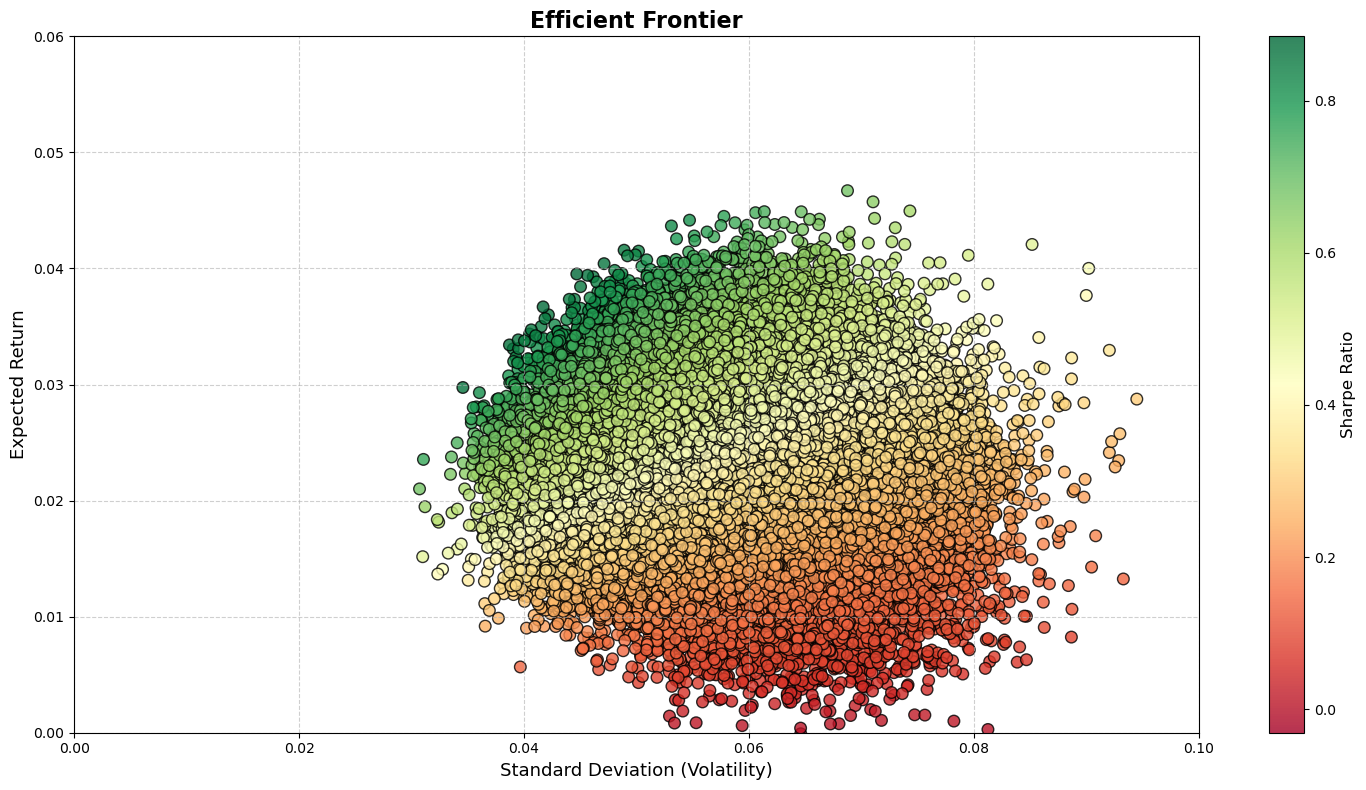

In [51]:
import matplotlib.pyplot as plt

# --- Efficient Frontier Scatter Plot ---
plt.figure(figsize=(15, 8))
sc = plt.scatter(
    portfolios['Volatility'],
    portfolios['Returns'],
    c=portfolios['Sharpe Ratio'],
    cmap='RdYlGn',
    edgecolors='black',
    s=70,
    alpha=0.8
)

# Add colorbar for Sharpe Ratio
cbar = plt.colorbar(sc)
cbar.set_label('Sharpe Ratio', fontsize=12)

# Axis labels, limits, and title
plt.xlabel('Standard Deviation (Volatility)', fontsize=13)
plt.ylabel('Expected Return', fontsize=13)
plt.title('Efficient Frontier', fontsize=16, fontweight='bold')

# Expanded limits
plt.xlim(0, 0.10)
plt.ylim(0, 0.06)

# Optional grid and aesthetic tweaks
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [52]:
min_volatility = portfolios['Volatility'].min()
max_sharpe = portfolios['Sharpe Ratio'].max()

sharpe_portfolio = portfolios.loc[portfolios['Sharpe Ratio'] == max_sharpe]
min_variance_port = portfolios.loc[portfolios['Volatility'] == min_volatility]
print(sharpe_portfolio)

       Returns  Volatility  Sharpe Ratio  ADBE weight  AMZN weight  BX weight  \
55002 0.039524    0.044684      0.884509     0.005045     0.041864   0.116835   

       GD weight  NKE weight  NVDA weight  SN weight  TSM weight  XOM weight  \
55002   0.149596    0.002678     0.005167   0.047326    0.000422    0.023079   

       AVDV weight  BTC weight  FNDB weight  REZ weight  VUG weight  \
55002     0.029940    0.105924     0.089929    0.083453    0.084143   

       VXUS weight  TBIL weight  
55002     0.063757     0.150841  


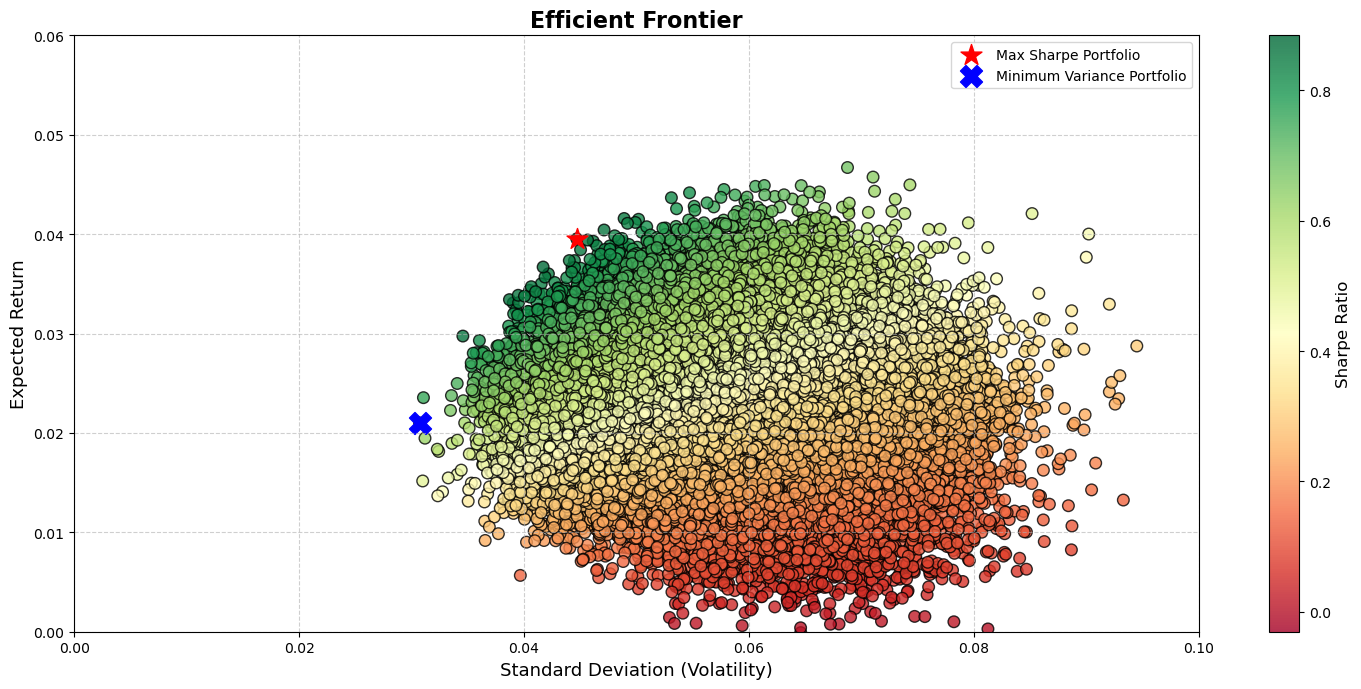

In [53]:
import matplotlib.pyplot as plt

# --- Efficient Frontier Scatter Plot (Matplotlib-only) ---
plt.figure(figsize=(15, 7))

# Main scatter: portfolios by Volatility and Return, color-coded by Sharpe Ratio
sc = plt.scatter(
    portfolios['Volatility'],
    portfolios['Returns'],
    c=portfolios['Sharpe Ratio'],
    cmap='RdYlGn',
    edgecolors='black',
    s=70,
    alpha=0.8
)

# Highlight special portfolios
plt.scatter(
    sharpe_portfolio['Volatility'],
    sharpe_portfolio['Returns'],
    color='red',
    marker='*',
    s=250,
    label='Max Sharpe Portfolio'
)

plt.scatter(
    min_variance_port['Volatility'],
    min_variance_port['Returns'],
    color='blue',
    marker='X',
    s=250,
    label='Minimum Variance Portfolio'
)

# Colorbar for Sharpe ratio
cbar = plt.colorbar(sc)
cbar.set_label('Sharpe Ratio', fontsize=12)

# Axes and styling
plt.xlabel('Standard Deviation (Volatility)', fontsize=13)
plt.ylabel('Expected Return', fontsize=13)
plt.title('Efficient Frontier', fontsize=16, fontweight='bold')

# Expanded limits
plt.xlim(0, 0.10)
plt.ylim(0, 0.06)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
sharpe_portfolio

,Returns,Volatility,Sharpe Ratio,ADBE weight,AMZN weight,BX weight,GD weight,NKE weight,NVDA weight,SN weight,TSM weight,XOM weight,AVDV weight,BTC weight,FNDB weight,REZ weight,VUG weight,VXUS weight,TBIL weight
49520,0.036158,0.040299,0.897239,0.005989,0.116657,0.090346,0.110297,0.007223,0.070859,0.069708,0.000327,0.018253,0.003365,0.032101,0.071499,0.082960,0.127279,0.060273,0.132864


In [28]:
portfolios.sort_values(by = ['Sharpe Ratio'], inplace=True, ascending=False)
portfolios

,Returns,Volatility,Sharpe Ratio,ADBE weight,AMZN weight,BX weight,GD weight,NKE weight,NVDA weight,SN weight,TSM weight,XOM weight,AVDV weight,BTC weight,FNDB weight,REZ weight,VUG weight,VXUS weight,TBIL weight
49520,0.036158,0.040299,0.897239,0.005989,0.116657,0.090346,0.110297,0.007223,0.070859,0.069708,0.000327,0.018253,0.003365,0.032101,0.071499,0.082960,0.127279,0.060273,0.132864
12467,0.037048,0.042058,0.880879,0.004123,0.025206,0.089854,0.116724,0.009675,0.063423,0.128706,0.001307,0.023832,0.123562,0.031695,0.016715,0.103712,0.113085,0.023521,0.124859
37066,0.028232,0.032681,0.863874,0.006065,0.009791,0.065935,0.069390,0.046107,0.046402,0.047207,0.004857,0.021769,0.119702,0.006317,0.142184,0.034115,0.136738,0.108139,0.135282
15999,0.037455,0.043620,0.858667,0.000314,0.061895,0.130352,0.078171,0.001210,0.094940,0.082429,0.010484,0.045208,0.091701,0.047558,0.000939,0.052135,0.116654,0.033110,0.152899
32360,0.039225,0.045949,0.853672,0.005542,0.065922,0.175023,0.092777,0.000204,0.047575,0.045390,0.001532,0.001948,0.089762,0.117017,0.053348,0.073825,0.024665,0.097163,0.108307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31443,-0.000011,0.058877,-0.000189,0.165743,0.040759,0.052681,0.050828,0.075747,0.016930,0.028580,0.084279,0.030351,0.162606,0.030875,0.102731,0.008847,0.126794,0.001491,0.020759
8418,-0.001419,0.078379,-0.018100,0.158182,0.094233,0.021018,0.099930,0.155067,0.151281,0.027727,0.133673,0.019617,0.014062,0.019618,0.005498,0.030205,0.049353,0.005734,0.014804
7060,-0.001311,0.070312,-0.018652,0.144799,0.007543,0.023719,0.106024,0.163771,0.038777,0.059681,0.098217,0.013889,0.058275,0.004847,0.075981,0.010510,0.142728,0.045864,0.005373
7815,-0.003714,0.071829,-0.051709,0.180750,0.088114,0.040604,0.035721,0.151346,0.049508,0.021482,0.116922,0.045558,0.073563,0.010771,0.038526,0.000439,0.025154,0.109838,0.011705



## 7. Write-Up — Discussion Prompts

- **ETF Selection Rationale:** Why are your chosen ETFs reasonable proxies for the target asset classes? Any liquidity/fee/coverage considerations?  
- **Bitcoin’s Role:** Where does `BTC-USD` land in your optimal portfolio? How sensitive is its weight to sample period and risk-free rate?  
- **Big Ideas Context:** Do your findings support or contradict the claim that Bitcoin can improve a diversified portfolio’s risk–return tradeoff? Under what conditions?  
- **Practical Concerns:** Rebalancing frequency, transaction costs, taxes, and investability (if using `BTC-USD` vs an ETF).

1) My current chosen ETFs and Stocks are representative of my current indivdiual investing portfolio. I've chosen these as a mix of tech, blended large/mid/small cap, international, real estate, bitcoin, and fixed income.
2) Bitcoin's percentage of my optimal portfolio is 3.21%. This weight is much more sensitive to the overall sample period and risk-free weight
3) My findings do support the idea that Bitcoin can improve a diversified portfolio's risk-return tradeoff, under the conditions that it is ~3%. 